In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

df = pd.read_excel(filename)

print(df.head())
print("Shape:", df.shape)

Saving RELIANCE.NS_1973-05-08_2025-03-01(1).xlsx to RELIANCE.NS_1973-05-08_2025-03-01(1).xlsx
Uploaded file: RELIANCE.NS_1973-05-08_2025-03-01(1).xlsx
                        date      open      high       low     close  \
0  1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901   
1  1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776   
2  1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116   
3  1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097   7.27628   
4  1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   

  adj_close     volume  
0  3.353593  104121369  
1  3.327513  168743308  
2  3.352778  209323879  
3  3.321809  216900264  
4   3.29899  166708467  
Shape: (7329, 7)


In [2]:



df["date"] = pd.to_datetime(df["date"], errors="coerce")


df["close"] = pd.to_numeric(df["close"], errors="coerce")


df = df.dropna(subset=["date", "close"])


df = df.sort_values("date").reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df[["date", "close"]].head())

print("\nLast 5 rows:")
print(df[["date", "close"]].tail())

Cleaned dataset shape: (7324, 7)

First 5 rows:
                       date     close
0 1996-01-01 00:00:00+05:30  7.345901
1 1996-01-02 00:00:00+05:30  7.288776
2 1996-01-03 00:00:00+05:30  7.344116
3 1996-01-04 00:00:00+05:30  7.276280
4 1996-01-05 00:00:00+05:30  7.226296

Last 5 rows:
                          date        close
7319 2025-02-21 00:00:00+05:30  1228.150024
7320 2025-02-24 00:00:00+05:30  1214.550049
7321 2025-02-25 00:00:00+05:30  1204.000000
7322 2025-02-27 00:00:00+05:30  1207.099976
7323 2025-02-28 00:00:00+05:30  1200.099976


In [3]:
df["daily_return"] = df["close"].pct_change() * 100
df = df.dropna(subset=["daily_return"])

print(df[["date", "close", "daily_return"]].head())
print("\nNumber of records:", len(df))

                       date     close  daily_return
1 1996-01-02 00:00:00+05:30  7.288776     -0.777646
2 1996-01-03 00:00:00+05:30  7.344116      0.759254
3 1996-01-04 00:00:00+05:30  7.276280     -0.923682
4 1996-01-05 00:00:00+05:30  7.226296     -0.686944
5 1996-01-08 00:00:00+05:30  6.937101     -4.001982

Number of records: 7323


In [4]:
period1 = df[
    (df["date"].dt.year >= 1996) &
    (df["date"].dt.year <= 2010)
]

period2 = df[
    (df["date"].dt.year >= 2011) &
    (df["date"].dt.year <= 2025)
]

print("1996–2010 records:", len(period1))
print("2011–2025 records:", len(period2))

1996–2010 records: 3830
2011–2025 records: 3493


In [5]:
print("1996–2010")
print("Mean:", period1["daily_return"].mean())
print("Standard Deviation:", period1["daily_return"].std())
print("Minimum:", period1["daily_return"].min())
print("Maximum:", period1["daily_return"].max())

print("\n2011–2025")
print("Mean:", period2["daily_return"].mean())
print("Standard Deviation:", period2["daily_return"].std())
print("Minimum:", period2["daily_return"].min())
print("Maximum:", period2["daily_return"].max())

1996–2010
Mean: 0.20352351639288105
Standard Deviation: 6.377723703471117
Minimum: -76.99449466310963
Maximum: 337.4775217734167

2011–2025
Mean: 0.06078400537396103
Standard Deviation: 1.7305552018321282
Minimum: -13.153886276678762
Maximum: 14.718038908094023


In [6]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    period1["daily_return"],
    period2["daily_return"],
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

T-statistic: 1.3324
P-value: 0.18281278401982476


In [7]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0")
    print("Conclusion: There is a statistically significant difference in average daily returns.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: There is no statistically significant difference in average daily returns.")

Decision: Fail to Reject H0
Conclusion: There is no statistically significant difference in average daily returns.


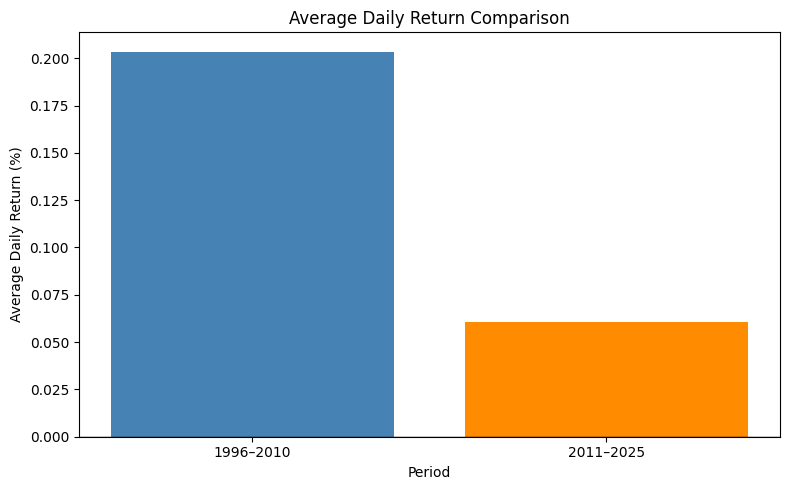

In [10]:
import matplotlib.pyplot as plt

means = [
    period1["daily_return"].mean(),
    period2["daily_return"].mean()
]

labels = ["1996–2010", "2011–2025"]

plt.figure(figsize=(8, 5))
plt.bar(labels, means, color=["steelblue", "darkorange"])

plt.axhline(0, color="black", linewidth=1)
plt.title("Average Daily Return Comparison")
plt.xlabel("Period")
plt.ylabel("Average Daily Return (%)")

plt.tight_layout()
plt.show()

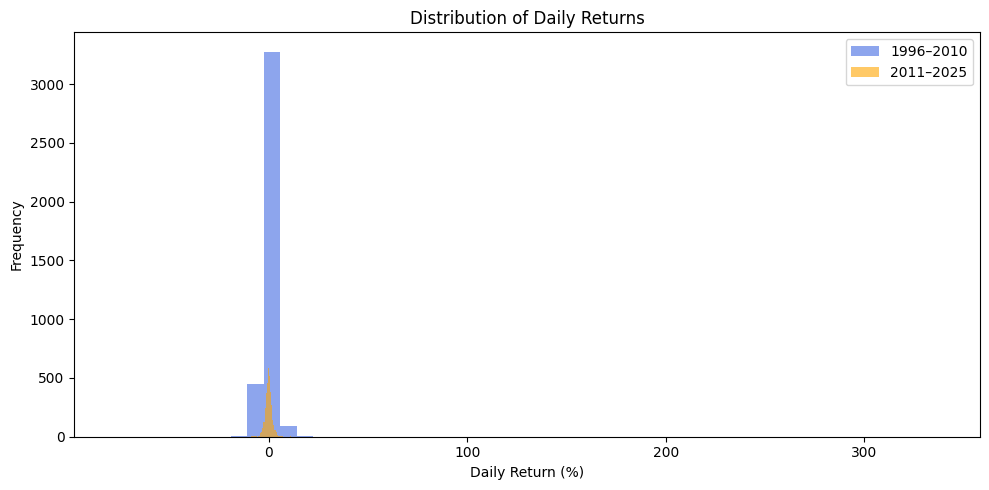

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    period1["daily_return"],
    bins=50,
    alpha=0.6,
    color="royalblue",
    label="1996–2010"
)

plt.hist(
    period2["daily_return"],
    bins=50,
    alpha=0.6,
    color="orange",
    label="2011–2025"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1764/2770317215.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


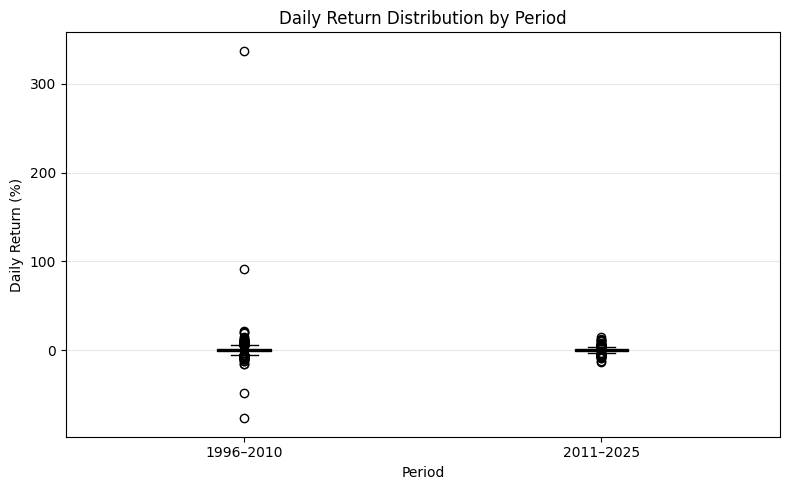

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [period1["daily_return"], period2["daily_return"]],
    labels=["1996–2010", "2011–2025"],
    patch_artist=True,
    boxprops=dict(facecolor="mediumseagreen"),
    medianprops=dict(color="black", linewidth=2)
)

plt.title("Daily Return Distribution by Period")
plt.xlabel("Period")
plt.ylabel("Daily Return (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

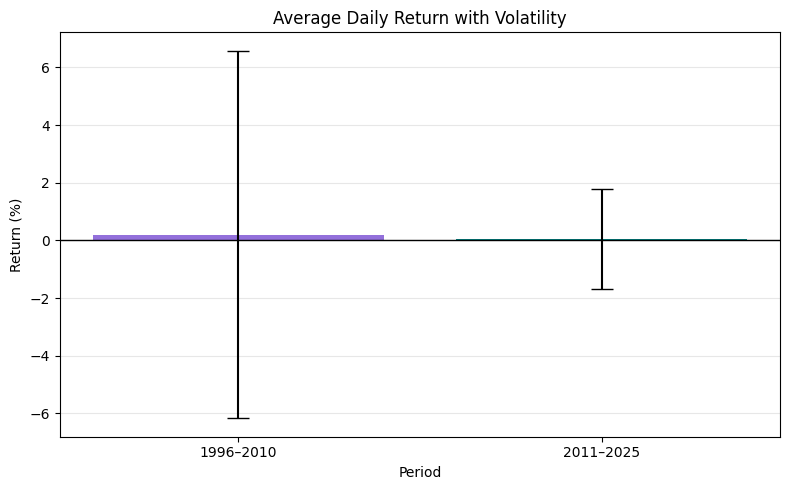

In [13]:
import matplotlib.pyplot as plt

means = [
    period1["daily_return"].mean(),
    period2["daily_return"].mean()
]

stds = [
    period1["daily_return"].std(),
    period2["daily_return"].std()
]

labels = ["1996–2010", "2011–2025"]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    means,
    yerr=stds,
    capsize=8,
    color=["mediumpurple", "teal"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Average Daily Return with Volatility")
plt.xlabel("Period")
plt.ylabel("Return (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
results = pd.DataFrame({
    "Period": ["1996–2010", "2011–2025"],
    "Records": [len(period1), len(period2)],
    "Mean Daily Return (%)": [
        period1["daily_return"].mean(),
        period2["daily_return"].mean()
    ],
    "Standard Deviation (%)": [
        period1["daily_return"].std(),
        period2["daily_return"].std()
    ]
})

print(results.round(4))

      Period  Records  Mean Daily Return (%)  Standard Deviation (%)
0  1996–2010     3830                 0.2035                  6.3777
1  2011–2025     3493                 0.0608                  1.7306


In [15]:
mean1 = period1["daily_return"].mean()
mean2 = period2["daily_return"].mean()

difference = mean2 - mean1

print("Mean Return - 1996–2010:", round(mean1, 6), "%")
print("Mean Return - 2011–2025:", round(mean2, 6), "%")
print("Difference:", round(difference, 6), "%")

Mean Return - 1996–2010: 0.203524 %
Mean Return - 2011–2025: 0.060784 %
Difference: -0.14274 %


In [16]:
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 35)

print("Null Hypothesis (H0):")
print("There is no significant difference in average daily returns.")

print("\nAlternative Hypothesis (H1):")
print("There is a significant difference in average daily returns.")

print("\nStatistical Test: Welch's Independent Two-Sample T-Test")
print("Significance Level:", 0.05)

print("\nT-statistic:", round(t_stat, 6))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("\nDecision: Reject H0")
    print("Result: Statistically significant difference found.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Result: No statistically significant difference found.")

HYPOTHESIS TESTING SUMMARY
Null Hypothesis (H0):
There is no significant difference in average daily returns.

Alternative Hypothesis (H1):
There is a significant difference in average daily returns.

Statistical Test: Welch's Independent Two-Sample T-Test
Significance Level: 0.05

T-statistic: 1.332352
P-value: 0.182813

Decision: Fail to Reject H0
Result: No statistically significant difference found.


In [17]:
df.to_csv("Reliance_Hypothesis_Testing_Data.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [18]:
plt.savefig("average_return_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>